# Movement Strategy Simulation

This notebook simulates each movement strategy with the same `MotorController` setup used in `backend.py`, then analyzes:
- each motor command over time
- reconstructed tactor position from resulting motor outputs (not requested path)
- wire consistency issues (too tight / inconsistent trilateration residual)

Default pattern (fully configurable):
1. Start at `(0, 0)`
2. Move right from center to `50%` of half-width
3. One clockwise circle
4. Return to `(0, 0)`


In [1]:
import math
from dataclasses import dataclass
from pathlib import Path
import sys
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

# Make imports work whether the notebook is launched from the repo root or from analysis/.
# Do not add any path outside this repository.
CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR if (CURRENT_DIR / 'motor_controller.py').exists() else CURRENT_DIR.parent
if not (REPO_ROOT / 'motor_controller.py').exists():
    raise FileNotFoundError(
        'Could not locate the repository root. Launch this notebook from the repo root '
        'or from analysis/.'
    )

repo_root_str = str(REPO_ROOT)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

from consts import EDGE_THRESHOLD, TOP_HEIGHT, TOP_WIDTH
from haptic_mapping import map_object_displacement_to_tactor
from motor_controller import FingerId, HandOrientation, MotorController, MovementStrategy

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


In [2]:
@dataclass
class SimulationConfig:
    # MotorController setup (mirrors backend usage)
    top_width: float = TOP_WIDTH
    top_height: float = TOP_HEIGHT
    edge_threshold: float = EDGE_THRESHOLD
    motor_spacing: float = 1000.0
    move_factor: float = 1.0
    diagonal_threshold: float = 0.5
    finger_id: FingerId = FingerId.INDEX
    hand_orientation: HandOrientation = HandOrientation.NOT_MIRRORED
    stiffness_value_normalized = 1

    # Pattern controls
    outward_fraction_of_half_width: float = 0.5
    # line_steps: int = 40
    # circle_steps: int = 220
    # return_steps: int = 40
    line_steps: int = 40
    circle_steps: int = 220
    return_steps: int = 40

    oppose_object_motion: bool = True
    # Analysis controls
    wire_residual_alert_threshold: float = 1.25

    # Live display controls
    live_plots: bool = False
    live_update_interval: int = 8


config = SimulationConfig()
config


SimulationConfig(top_width=640, top_height=480, edge_threshold=30, motor_spacing=1000.0, move_factor=1.0, diagonal_threshold=0.5, finger_id=<FingerId.INDEX: 1>, hand_orientation=<HandOrientation.NOT_MIRRORED: 'not_mirrored'>, outward_fraction_of_half_width=0.5, line_steps=40, circle_steps=220, return_steps=40, oppose_object_motion=True, wire_residual_alert_threshold=1.25, live_plots=False, live_update_interval=8)

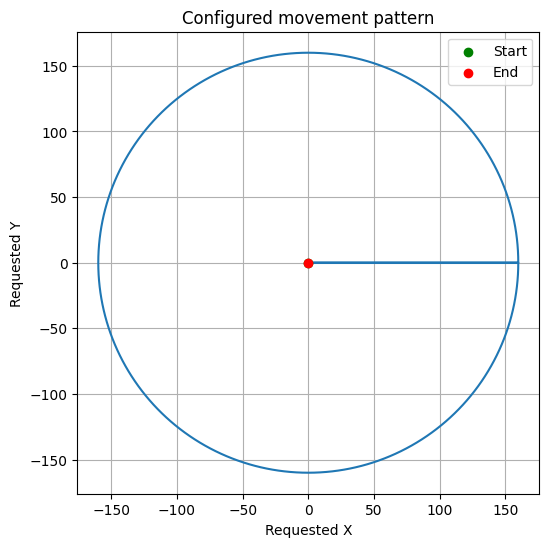

,step,segment,x,y
0,0,outward_right,0.0,0.0
1,1,outward_right,4.0,0.0
2,2,outward_right,8.0,0.0
3,3,outward_right,12.0,0.0
4,4,outward_right,16.0,0.0


In [3]:
DEFAULT_PATTERN_TEMPLATE: list[dict[str, Any]] = [
    {
        'type': 'line',
        'name': 'outward_right',
        'start': (0.0, 0.0),
        'end': '$OUTWARD_POINT',
        'steps': 'line_steps',
    },
    {
        'type': 'circle',
        'name': 'clockwise_circle',
        'center': (0.0, 0.0),
        'radius': '$OUTWARD_RADIUS',
        'start_angle_deg': 0.0,
        'sweep_angle_deg': -360.0,
        'steps': 'circle_steps',
    },
    {
        'type': 'line',
        'name': 'back_to_center',
        'start': '$OUTWARD_POINT',
        'end': (0.0, 0.0),
        'steps': 'return_steps',
    },
]


def _resolve_value(value: Any, context: dict[str, Any], cfg: SimulationConfig) -> Any:
    if isinstance(value, str):
        if value.startswith('$'):
            return context[value]
        if hasattr(cfg, value):
            return getattr(cfg, value)
    return value


def build_pattern_points(
    cfg: SimulationConfig,
    pattern_template: list[dict[str, Any]] | None = None,
) -> pd.DataFrame:
    template = pattern_template or DEFAULT_PATTERN_TEMPLATE

    half_width = cfg.top_width / 2.0
    outward_x = half_width * cfg.outward_fraction_of_half_width
    context = {
        '$OUTWARD_POINT': (outward_x, 0.0),
        '$OUTWARD_RADIUS': outward_x,
    }

    rows: list[dict[str, float | str]] = []
    include_start = True

    for segment in template:
        segment_type = str(segment['type'])
        segment_name = str(segment.get('name', segment_type))
        steps = int(_resolve_value(segment['steps'], context, cfg))
        if steps < 1:
            raise ValueError(f'Invalid steps for {segment_name}: {steps}')

        if segment_type == 'line':
            start = np.array(_resolve_value(segment['start'], context, cfg), dtype=float)
            end = np.array(_resolve_value(segment['end'], context, cfg), dtype=float)

            t_values = np.linspace(0.0, 1.0, num=steps + 1)
            if not include_start:
                t_values = t_values[1:]

            for t in t_values:
                point = start + t * (end - start)
                rows.append({'segment': segment_name, 'x': float(point[0]), 'y': float(point[1])})

        elif segment_type == 'circle':
            center = np.array(_resolve_value(segment['center'], context, cfg), dtype=float)
            radius = float(_resolve_value(segment['radius'], context, cfg))
            start_angle = math.radians(float(_resolve_value(segment.get('start_angle_deg', 0.0), context, cfg)))
            sweep_angle = math.radians(float(_resolve_value(segment.get('sweep_angle_deg', -360.0), context, cfg)))

            angles = np.linspace(start_angle, start_angle + sweep_angle, num=steps + 1)
            if not include_start:
                angles = angles[1:]

            for angle in angles:
                x = center[0] + radius * math.cos(angle)
                y = center[1] + radius * math.sin(angle)
                rows.append({'segment': segment_name, 'x': float(x), 'y': float(y)})

        else:
            raise ValueError(f'Unsupported segment type: {segment_type}')

        include_start = False

    path_df = pd.DataFrame(rows)
    path_df.insert(0, 'step', np.arange(len(path_df), dtype=int))
    return path_df


pattern_df = build_pattern_points(config)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pattern_df['x'], pattern_df['y'], linewidth=1.5)
ax.scatter(pattern_df.iloc[0]['x'], pattern_df.iloc[0]['y'], color='green', label='Start', zorder=3)
ax.scatter(pattern_df.iloc[-1]['x'], pattern_df.iloc[-1]['y'], color='red', label='End', zorder=3)
ax.set_title('Configured movement pattern')
ax.set_xlabel('Requested X')
ax.set_ylabel('Requested Y')
ax.set_aspect('equal', 'box')
ax.legend()
plt.show()

pattern_df.head()


In [4]:
def get_motor_anchors(motor_spacing: float) -> np.ndarray:
    h = motor_spacing * math.sqrt(3.0) / 3.0
    # Clockwise motor order: 0=top, 1=bottom-right, 2=bottom-left
    return np.array(
        [
            [0.0, 2.0 * h / 3.0],
            [motor_spacing / 2.0, -h / 3.0],
            [-motor_spacing / 2.0, -h / 3.0],
        ],
        dtype=float,
    )


def reconstruct_tactor_xy(
    final_lengths: np.ndarray,
    anchors: np.ndarray,
) -> tuple[float, float, float, np.ndarray, np.ndarray]:
    # Linearized trilateration from three anchor distances
    p1 = anchors[0]
    r1 = final_lengths[0]

    A = []
    b = []
    for i in (1, 2):
        xi, yi = anchors[i]
        ri = final_lengths[i]
        A.append([2.0 * (xi - p1[0]), 2.0 * (yi - p1[1])])
        b.append(
            (r1 ** 2 - ri ** 2)
            - (p1[0] ** 2 - xi ** 2)
            - (p1[1] ** 2 - yi ** 2)
        )

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    solution, *_ = np.linalg.lstsq(A, b, rcond=None)
    x = float(solution[0])
    y = float(solution[1])

    predicted_lengths = np.linalg.norm(anchors - np.array([x, y]), axis=1)
    length_error = predicted_lengths - final_lengths
    residual_rmse = float(np.sqrt(np.mean(length_error ** 2)))

    return x, y, residual_rmse, predicted_lengths, length_error


In [5]:
def show_live_state(partial_df: pd.DataFrame, strategy_name: str, alert_threshold: float) -> None:
    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    idx0 = int(partial_df['motor_index_0'].iloc[0])
    idx1 = int(partial_df['motor_index_1'].iloc[0])
    idx2 = int(partial_df['motor_index_2'].iloc[0])

    axes[0].plot(partial_df['step'], partial_df['motor_0'], label=f'Motor {idx0}')
    axes[0].plot(partial_df['step'], partial_df['motor_1'], label=f'Motor {idx1}')
    axes[0].plot(partial_df['step'], partial_df['motor_2'], label=f'Motor {idx2}')
    axes[0].set_title(f'{strategy_name}: motor commands')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Motor position command')
    axes[0].legend()

    axes[1].plot(
        partial_df['object_x'],
        partial_df['object_y'],
        '--',
        label='Virtual object path',
        alpha=0.8,
        zorder=1,
    )
    axes[1].plot(
        partial_df['tactor_x'],
        partial_df['tactor_y'],
        label='Reconstructed tactor',
        linewidth=2,
        zorder=2,
    )

    issues = partial_df[partial_df['wire_issue']]
    if not issues.empty:
        axes[1].scatter(
            issues['tactor_x'],
            issues['tactor_y'],
            c='red',
            s=42,
            marker='o',
            edgecolors='black',
            linewidths=0.8,
            label='Wire issue',
            zorder=10,
        )

    axes[1].set_title(f'{strategy_name}: virtual object vs reconstructed tactor')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_aspect('equal', 'box')
    axes[1].legend(loc='upper right')

    fig.suptitle(f'Live update | issue threshold={alert_threshold:.2f}', y=1.03)
    plt.tight_layout()
    display(fig)
    plt.close(fig)


def simulate_strategy(
    strategy: MovementStrategy,
    pattern: pd.DataFrame,
    cfg: SimulationConfig,
) -> pd.DataFrame:
    controller = MotorController(
        movement_strategy=strategy,
        top_width=cfg.top_width,
        top_height=cfg.top_height,
        edge_threshold=cfg.edge_threshold,
        motor_spacing=cfg.motor_spacing,
        move_factor=cfg.move_factor,
        diagonal_threshold=cfg.diagonal_threshold,
        hand_orientation=cfg.hand_orientation,
    )

    base_idx = controller._get_base_index(cfg.finger_id)
    motor_indices = [base_idx + i for i in range(3)]
    current_motor_positions = {idx: 0 for idx in motor_indices}

    anchors = get_motor_anchors(controller._motor_spacing)
    initial_lengths = np.linalg.norm(anchors - np.array([0.0, 0.0]), axis=1)

    rows: list[dict[str, Any]] = []

    final_step = int(pattern['step'].iat[-1])
    update_every = max(1, cfg.live_update_interval)

    for _, point in pattern.iterrows():
        step = int(point['step'])
        object_x = float(point['x'])
        object_y = float(point['y'])
        segment = str(point['segment'])

        target_x, target_y = map_object_displacement_to_tactor(
            obj_x=object_x,
            obj_y=object_y,
            oppose_motion=cfg.oppose_object_motion,
        )

        movements = controller.calculate_motor_movements(
            finger_id=cfg.finger_id,
            stiffness_value=cfg.stiffness_value_normalized,
            obj_x=target_x,
            obj_y=target_y,
            motors_enabled=True,
            reset_to_origin=False,
        )

        for movement in movements:
            if movement.index in current_motor_positions:
                current_motor_positions[movement.index] = movement.pos

        motor_offsets = np.array([current_motor_positions[idx] for idx in motor_indices], dtype=float)
        final_lengths = initial_lengths + motor_offsets

        wire_too_tight = bool(np.any(final_lengths <= 0.0))
        if wire_too_tight:
            tactor_x = float('nan')
            tactor_y = float('nan')
            residual_rmse = float('inf')
            length_error = np.array([float('nan'), float('nan'), float('nan')], dtype=float)
            dominant_wire_motor_index = -1
            dominant_wire_error = float('nan')
        else:
            tactor_x, tactor_y, residual_rmse, _, length_error = reconstruct_tactor_xy(final_lengths, anchors)
            dominant_wire_idx = int(np.argmax(np.abs(length_error)))
            dominant_wire_motor_index = motor_indices[dominant_wire_idx]
            dominant_wire_error = float(abs(length_error[dominant_wire_idx]))

        tactor_error = float('nan')
        if not math.isnan(tactor_x) and not math.isnan(tactor_y):
            tactor_error = float(math.hypot(tactor_x - target_x, tactor_y - target_y))

        wire_issue = wire_too_tight or (residual_rmse > cfg.wire_residual_alert_threshold)

        rows.append(
            {
                'strategy': strategy.value,
                'step': step,
                'segment': segment,
                'object_x': object_x,
                'object_y': object_y,
                'target_x': target_x,
                'target_y': target_y,
                'motor_index_0': motor_indices[0],
                'motor_index_1': motor_indices[1],
                'motor_index_2': motor_indices[2],
                'motor_0': float(motor_offsets[0]),
                'motor_1': float(motor_offsets[1]),
                'motor_2': float(motor_offsets[2]),
                'wire_length_0': float(final_lengths[0]),
                'wire_length_1': float(final_lengths[1]),
                'wire_length_2': float(final_lengths[2]),
                'tactor_x': tactor_x,
                'tactor_y': tactor_y,
                'tactor_error': tactor_error,
                'wire_residual_rmse': float(residual_rmse),
                'wire_too_tight': wire_too_tight,
                'wire_issue': wire_issue,
                'dominant_wire_motor_index': dominant_wire_motor_index,
                'dominant_wire_error': dominant_wire_error,
            }
        )

        if cfg.live_plots and (step % update_every == 0 or step == final_step):
            show_live_state(pd.DataFrame(rows), strategy.value, cfg.wire_residual_alert_threshold)

    return pd.DataFrame(rows)


In [6]:
strategies = [
    MovementStrategy.CARDINAL,
    MovementStrategy.CARDINAL_DIAGONAL,
    MovementStrategy.FREE_FORM,
    MovementStrategy.IK,
]

pattern_df = build_pattern_points(config)
results = [simulate_strategy(strategy, pattern_df, config) for strategy in strategies]
all_results = pd.concat(results, ignore_index=True)

print(f'Path points: {len(pattern_df)}')
print(f'Strategies: {len(strategies)}')
print(f'Total rows: {len(all_results)}')
all_results.head()


Path points: 301
Strategies: 4
Total rows: 1204


,strategy,step,segment,object_x,object_y,target_x,target_y,motor_index_0,motor_index_1,motor_index_2,...,wire_length_1,wire_length_2,tactor_x,tactor_y,tactor_error,wire_residual_rmse,wire_too_tight,wire_issue,dominant_wire_motor_index,dominant_wire_error
0,cardinal,0,outward_right,0.0,0.0,-0.0,-0.0,3,4,5,...,535.758376,535.758376,0.000000,-5.040931e-14,5.040931e-14,3.281856e-14,False,False,3,5.684342e-14
1,cardinal,1,outward_right,4.0,0.0,-4.0,-0.0,3,4,5,...,538.758376,532.758376,-3.214550,7.794229e-03,7.854884e-01,4.633262e-03,False,False,3,5.629203e-03
2,cardinal,2,outward_right,8.0,0.0,-8.0,-0.0,3,4,5,...,542.758376,528.758376,-7.500617,4.243524e-02,5.011825e-01,2.522917e-02,False,False,3,3.064880e-02
3,cardinal,3,outward_right,12.0,0.0,-12.0,-0.0,3,4,5,...,546.758376,524.758376,-11.786684,1.047891e-01,2.376644e-01,6.231675e-02,False,False,3,7.568782e-02
4,cardinal,4,outward_right,16.0,0.0,-16.0,-0.0,3,4,5,...,549.758376,521.758376,-15.001235,1.697410e-01,1.013087e+00,1.009701e-01,False,False,3,1.226086e-01


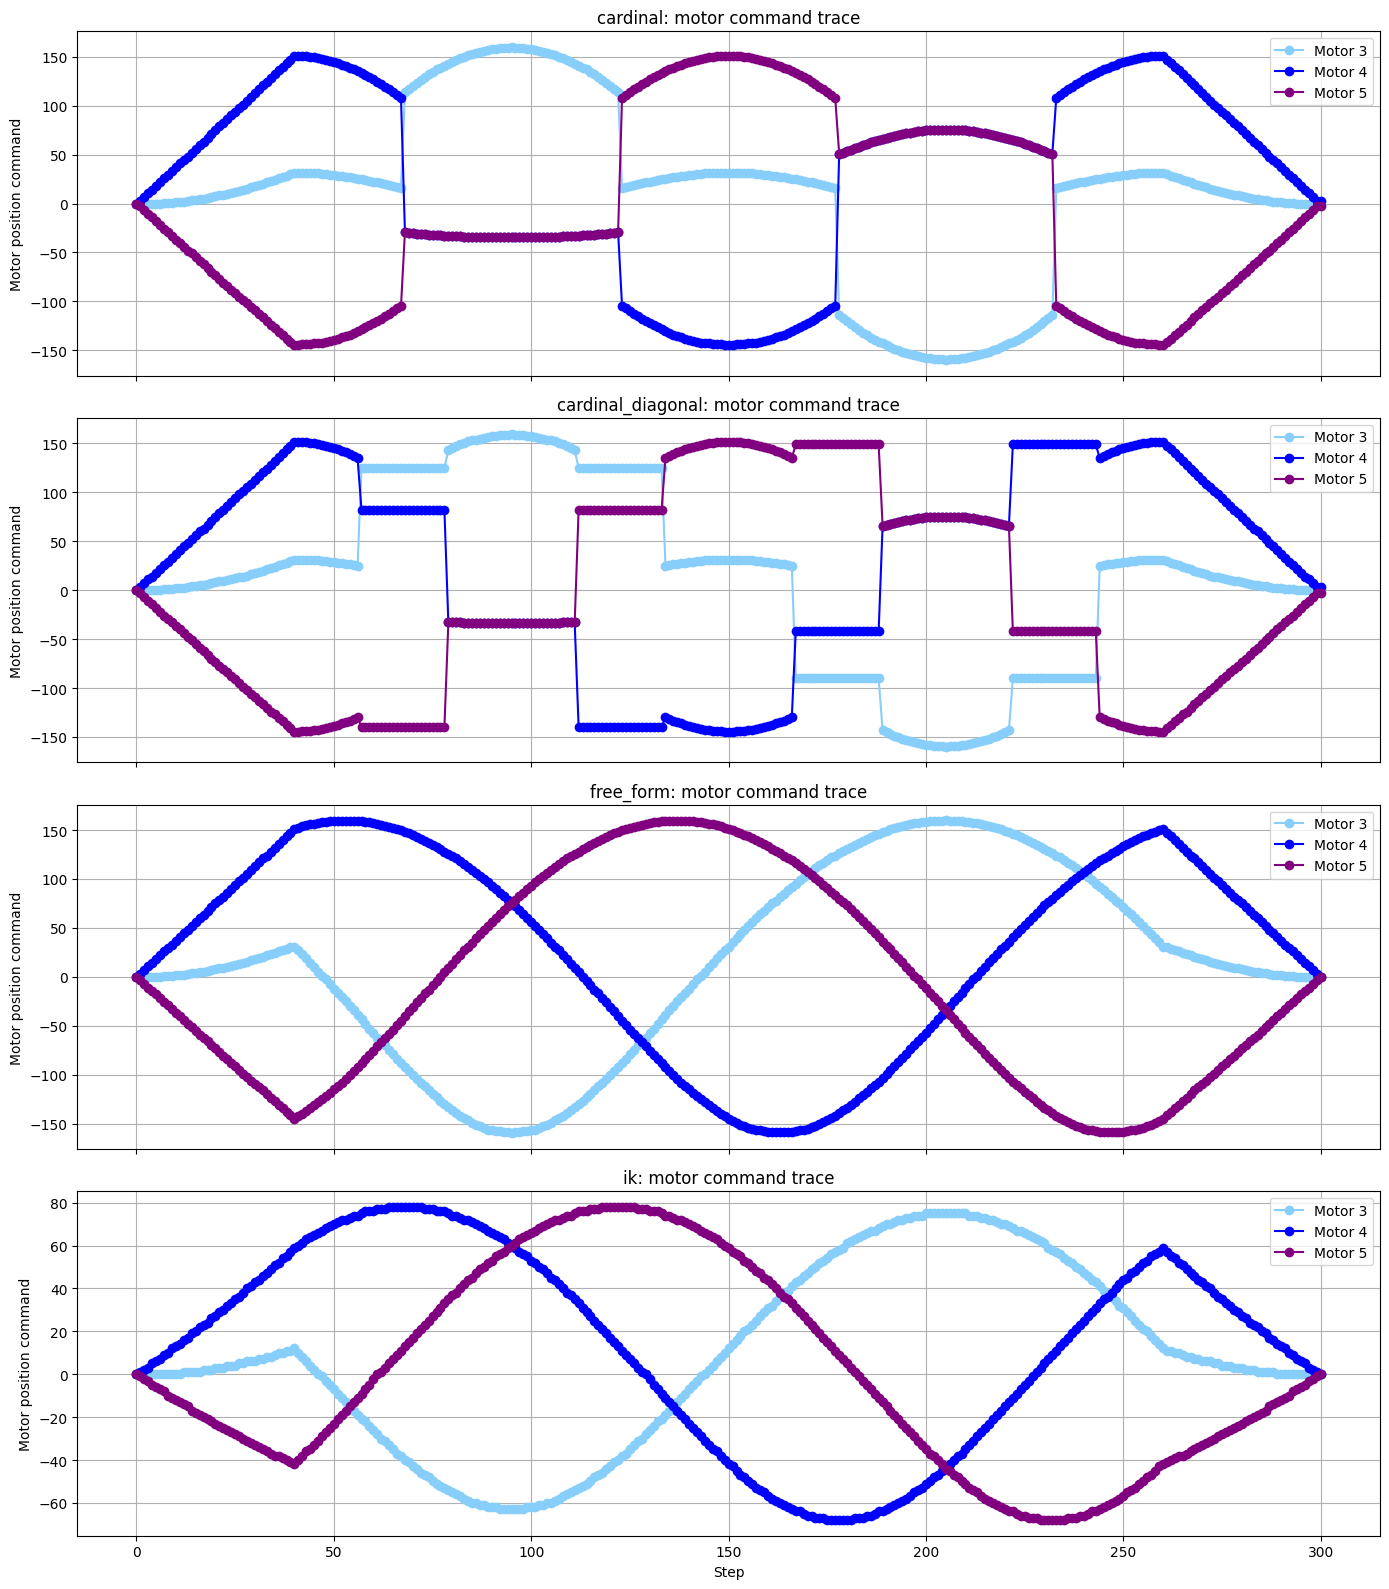

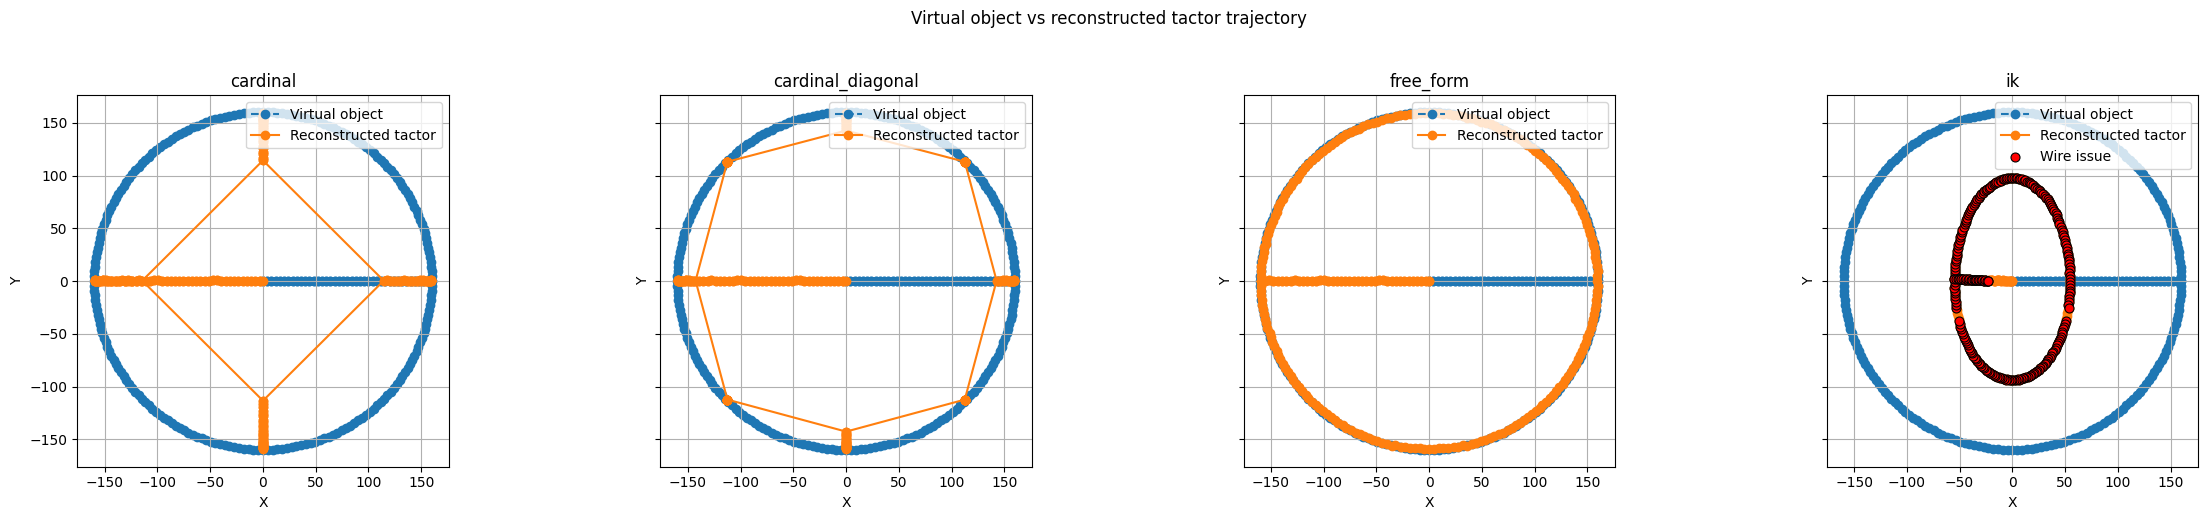

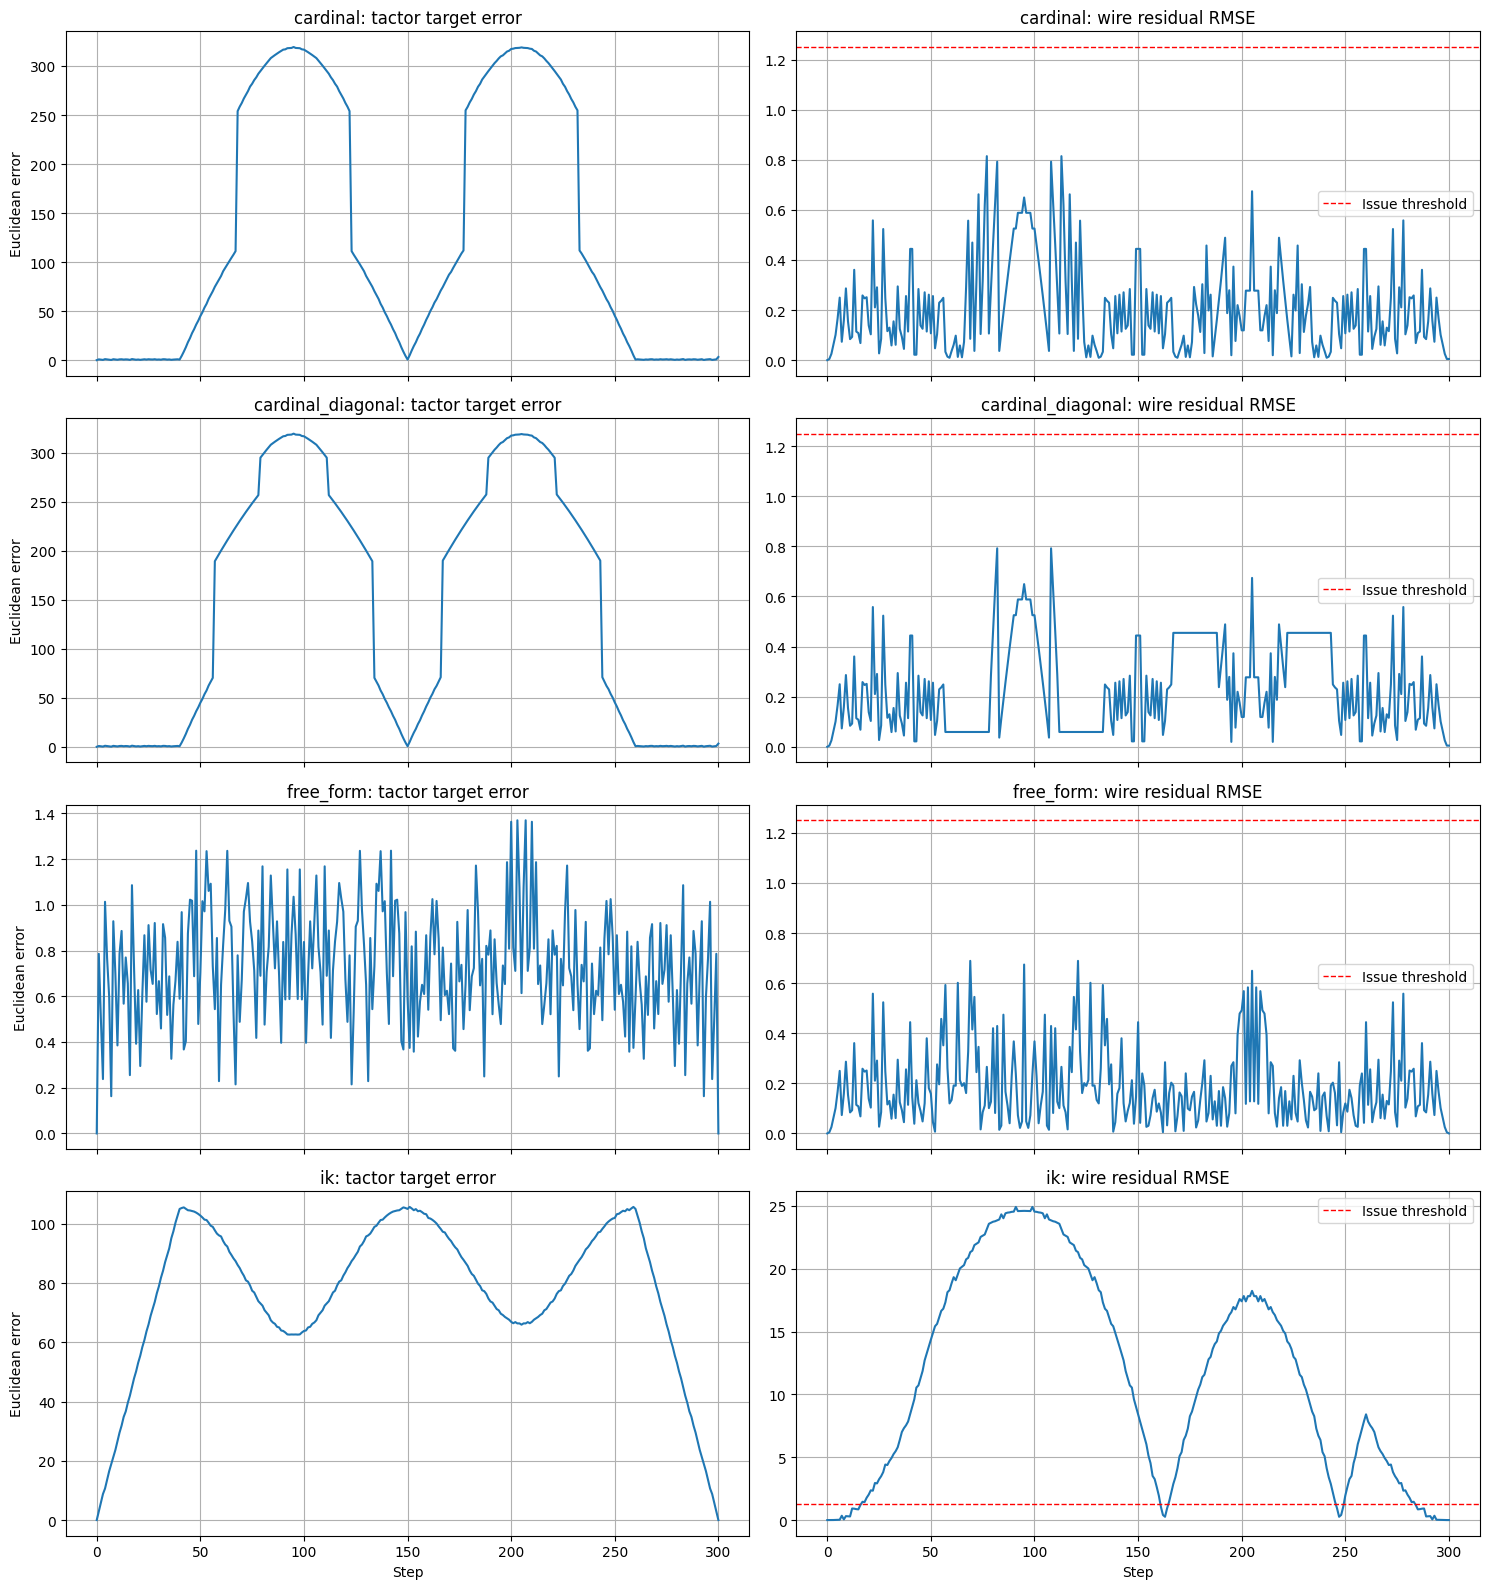

Strategy summary:


,mean_tactor_error,max_tactor_error,mean_wire_residual,max_wire_residual,issue_steps,issue_ratio
strategy,,,,,,
cardinal,130.105445,319.386456,0.211060,0.814231,0,0.000000
cardinal_diagonal,142.104277,319.386456,0.236269,0.792197,0,0.000000
free_form,0.730655,1.369523,0.186385,0.688820,0,0.000000
ik,76.903447,105.726119,11.423817,24.924250,259,0.860465


Wire issues detected in 259 steps.


,strategy,step,segment,target_x,target_y,tactor_x,tactor_y,wire_too_tight,wire_residual_rmse,dominant_wire_motor_index,dominant_wire_error
920,ik,17,outward_right,-68.000000,-0.000000,-23.102110,0.457412,False,1.454530,3,1.763907
921,ik,18,outward_right,-72.000000,-0.000000,-24.176627,0.495518,False,1.431689,3,1.735989
922,ik,19,outward_right,-76.000000,-0.000000,-25.812402,1.021419,False,1.776145,3,2.154571
923,ik,20,outward_right,-80.000000,-0.000000,-26.887919,0.392857,False,2.025645,3,2.453891
924,ik,21,outward_right,-84.000000,-0.000000,-28.527694,0.925687,False,2.366037,3,2.867401
...,...,...,...,...,...,...,...,...,...,...,...
1015,ik,112,clockwise_circle,74.666772,141.509269,25.381110,86.447160,False,23.581444,3,32.369871
1016,ik,113,clockwise_circle,78.677268,139.319372,26.516627,84.888039,False,23.157860,3,31.718481
1017,ik,114,clockwise_circle,82.623594,137.015845,27.648144,83.330651,False,22.731735,3,31.065901
1018,ik,115,clockwise_circle,86.502531,134.600565,29.387919,82.305226,False,22.636234,3,30.881503


In [7]:
def evenly_sample_steps(part: pd.DataFrame, sample_count: int) -> pd.DataFrame:
    if sample_count < 2:
        raise ValueError('sample_count must be at least 2.')

    if part.empty:
        return part

    sampled_len = min(sample_count, len(part))
    sampled_indices = np.linspace(0, len(part) - 1, num=sampled_len, dtype=int)
    sampled_indices = np.unique(sampled_indices)
    return part.iloc[sampled_indices]

def plot_motor_movements(df: pd.DataFrame, sample_count: int | None) -> None:
    strategy_names = [s.value for s in strategies]
    motor_colors = {
        0: 'lightskyblue',
        1: 'blue',
        2: 'purple',
    }
    fig, axes = plt.subplots(len(strategy_names), 1, figsize=(14, 4 * len(strategy_names)), sharex=True)
    if len(strategy_names) == 1:
        axes = [axes]

    for i, strategy_name in enumerate(strategy_names):
        ax = axes[i]
        part = df[df['strategy'] == strategy_name].reset_index(drop=True)
        if sample_count:
            part = evenly_sample_steps(part, sample_count)
        idx0 = int(part['motor_index_0'].iloc[0])
        idx1 = int(part['motor_index_1'].iloc[0])
        idx2 = int(part['motor_index_2'].iloc[0])

        ax.plot(part['step'], part['motor_0'], '-o', label=f'Motor {idx0}', color=motor_colors[0])
        ax.plot(part['step'], part['motor_1'], '-o', label=f'Motor {idx1}', color=motor_colors[1])
        ax.plot(part['step'], part['motor_2'], '-o', label=f'Motor {idx2}', color=motor_colors[2])
        ax.set_title(f'{strategy_name}: motor command trace' + (f' ({len(part)} samples)' if sample_count else ''))
        ax.set_ylabel('Motor position command')
        ax.legend()

    axes[-1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()

def plot_tactor_paths(df: pd.DataFrame, sample_count: int | None) -> None:
    strategy_names = [s.value for s in strategies]
    fig, axes = plt.subplots(1, len(strategy_names), figsize=(6 * len(strategy_names), 5), sharex=True, sharey=True)
    if len(strategy_names) == 1:
        axes = [axes]

    for i, strategy_name in enumerate(strategy_names):
        ax = axes[i]
        part = df[df['strategy'] == strategy_name].reset_index(drop=True)
        if sample_count:
            part = evenly_sample_steps(part, sample_count)

        ax.plot(
            part['object_x'],
            part['object_y'],
            '--o',
            label='Virtual object',
            zorder=1,
        )
        ax.plot(
            part['tactor_x'],
            part['tactor_y'],
            '-o',
            label='Reconstructed tactor',
            zorder=2,
        )

        issues = part[part['wire_issue']]
        if not issues.empty:
            ax.scatter(
                issues['tactor_x'],
                issues['tactor_y'],
                c='red',
                s=42,
                marker='o',
                edgecolors='black',
                linewidths=0.8,
                label='Wire issue',
                zorder=10,
            )

        ax.set_title(f'{strategy_name}' + (f' ({len(part)} samples)' if sample_count else ''))
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_aspect('equal', 'box')
        ax.legend(loc='upper right')

    plt.suptitle('Virtual object vs reconstructed tactor trajectory', y=1.03)
    plt.tight_layout()
    plt.show()


def plot_error_metrics(df: pd.DataFrame, alert_threshold: float) -> None:
    strategy_names = [s.value for s in strategies]
    fig, axes = plt.subplots(len(strategy_names), 2, figsize=(15, 4 * len(strategy_names)), sharex=True)
    if len(strategy_names) == 1:
        axes = np.array([axes])

    for i, strategy_name in enumerate(strategy_names):
        part = df[df['strategy'] == strategy_name]

        axes[i, 0].plot(part['step'], part['tactor_error'])
        axes[i, 0].set_title(f'{strategy_name}: tactor target error')
        axes[i, 0].set_ylabel('Euclidean error')

        axes[i, 1].plot(part['step'], part['wire_residual_rmse'])
        axes[i, 1].axhline(alert_threshold, color='red', linestyle='--', linewidth=1, label='Issue threshold')
        axes[i, 1].set_title(f'{strategy_name}: wire residual RMSE')
        axes[i, 1].legend()

    axes[-1, 0].set_xlabel('Step')
    axes[-1, 1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()


plot_motor_movements(all_results, sample_count=0)
plot_tactor_paths(all_results, sample_count=0)
plot_error_metrics(all_results, config.wire_residual_alert_threshold)

summary_source = all_results.replace([np.inf, -np.inf], np.nan)
summary = (
    summary_source.groupby('strategy')
    .agg(
        mean_tactor_error=('tactor_error', 'mean'),
        max_tactor_error=('tactor_error', 'max'),
        mean_wire_residual=('wire_residual_rmse', 'mean'),
        max_wire_residual=('wire_residual_rmse', 'max'),
        issue_steps=('wire_issue', 'sum'),
        issue_ratio=('wire_issue', 'mean'),
    )
    .sort_index()
)

print('Strategy summary:')
display(summary)

issues = all_results[all_results['wire_issue']].copy()
if issues.empty:
    print('No wire consistency issues detected at the configured threshold.')
else:
    print(f'Wire issues detected in {len(issues)} steps.')
    issue_cols = [
        'strategy',
        'step',
        'segment',
        'target_x',
        'target_y',
        'tactor_x',
        'tactor_y',
        'wire_too_tight',
        'wire_residual_rmse',
        'dominant_wire_motor_index',
        'dominant_wire_error',
    ]
    display(issues[issue_cols].head(100))


## IK MovementStrategy comparison

The IK path now runs through the same in-repository `MovementStrategy.IK` implementation used by `backend.py`.
There are no outside-repo path imports or notebook-local IK actuator calculations here; the notebook compares the public motor-command output produced by `MotorController.calculate_motor_movements(...)` for each strategy.


In [8]:
def summarize_strategy_results(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in strategies:
        part = df[df['strategy'] == strategy.value]
        rows.append(
            {
                'strategy': strategy.value,
                'rows': len(part),
                'wire_issue_count': int(part['wire_issue'].sum()),
                'max_tactor_error': float(part['tactor_error'].max(skipna=True)),
                'max_wire_residual_rmse': float(part['wire_residual_rmse'].replace(np.inf, np.nan).max(skipna=True)),
                'motor_0_min': float(part['motor_0'].min(skipna=True)),
                'motor_0_max': float(part['motor_0'].max(skipna=True)),
                'motor_1_min': float(part['motor_1'].min(skipna=True)),
                'motor_1_max': float(part['motor_1'].max(skipna=True)),
                'motor_2_min': float(part['motor_2'].min(skipna=True)),
                'motor_2_max': float(part['motor_2'].max(skipna=True)),
            }
        )
    return pd.DataFrame(rows)


ik_results = all_results[all_results['strategy'] == MovementStrategy.IK.value].reset_index(drop=True)
if ik_results.empty:
    raise RuntimeError('MovementStrategy.IK was not included in strategies or produced no rows.')

ik_controller = MotorController(
    movement_strategy=MovementStrategy.IK,
    top_width=config.top_width,
    top_height=config.top_height,
    edge_threshold=config.edge_threshold,
    motor_spacing=config.motor_spacing,
    move_factor=config.move_factor,
    diagonal_threshold=config.diagonal_threshold,
    hand_orientation=config.hand_orientation,
)
ik_solver_path = Path(ik_controller._get_ik_module().__file__).resolve()

print('IK strategy is simulated through MotorController(MovementStrategy.IK).')
print(f'IK solver path: {ik_solver_path.relative_to(REPO_ROOT)}')
print(
    'Backend-equivalent inputs: oppose_object_motion=' 
    f'{config.oppose_object_motion}, stiffness={config.stiffness_value_normalized}, '
    f'move_factor={config.move_factor}, motor_spacing={config.motor_spacing}.'
)

display(summarize_strategy_results(all_results))
print('IK sample rows:')
display(
    ik_results[
        [
            'step', 'segment', 'object_x', 'object_y', 'target_x', 'target_y',
            'motor_index_0', 'motor_0', 'motor_index_1', 'motor_1', 'motor_index_2', 'motor_2',
            'wire_issue', 'tactor_error', 'wire_residual_rmse',
        ]
    ].head(10)
)


IK strategy is simulated through MotorController(MovementStrategy.IK).
IK solver path: kinematics\unified_ik_starter.py
Backend-equivalent inputs: oppose_object_motion=True, stiffness=1, move_factor=1.0, motor_spacing=1000.0.


,strategy,rows,wire_issue_count,max_tactor_error,max_wire_residual_rmse,motor_0_min,motor_0_max,motor_1_min,motor_1_max,motor_2_min,motor_2_max
0,cardinal,301,0,319.386456,0.814231,-160.0,160.0,-145.0,151.0,-145.0,151.0
1,cardinal_diagonal,301,0,319.386456,0.792197,-160.0,160.0,-145.0,151.0,-145.0,151.0
2,free_form,301,0,1.369523,0.688820,-160.0,160.0,-159.0,159.0,-159.0,159.0
3,ik,301,259,105.726119,24.924250,-63.0,75.0,-68.0,78.0,-68.0,78.0


IK sample rows:


,step,segment,object_x,object_y,target_x,target_y,motor_index_0,motor_0,motor_index_1,motor_1,motor_index_2,motor_2,wire_issue,tactor_error,wire_residual_rmse
0,0,outward_right,0.0,0.0,-0.0,-0.0,3,0.0,4,0.0,5,0.0,False,5.040931e-14,3.281856e-14
1,1,outward_right,4.0,0.0,-4.0,-0.0,3,0.0,4,1.0,5,-1.0,False,2.928483e+00,5.147921e-04
2,2,outward_right,8.0,0.0,-8.0,-0.0,3,0.0,4,2.0,5,-2.0,False,5.856968e+00,2.059190e-03
3,3,outward_right,12.0,0.0,-12.0,-0.0,3,0.0,4,3.0,5,-3.0,False,8.785453e+00,4.633262e-03
4,4,outward_right,16.0,0.0,-16.0,-0.0,3,0.0,4,5.0,5,-5.0,False,1.064244e+01,1.287091e-02
5,5,outward_right,20.0,0.0,-20.0,-0.0,3,0.0,4,6.0,5,-6.0,False,1.357094e+01,1.853485e-02
6,6,outward_right,24.0,0.0,-24.0,-0.0,3,0.0,4,7.0,5,-7.0,False,1.649944e+01,2.522917e-02
7,7,outward_right,28.0,0.0,-28.0,-0.0,3,0.0,4,9.0,5,-8.0,False,1.889095e+01,3.444477e-01
8,8,outward_right,32.0,0.0,-32.0,-0.0,3,0.0,4,10.0,5,-10.0,False,2.128501e+01,5.149755e-02
9,9,outward_right,36.0,0.0,-36.0,-0.0,3,0.0,4,12.0,5,-11.0,False,2.367313e+01,3.133956e-01
